# Time Series Analysis

This notebook discusses MA and ARMA models.

## Load Packages and Extra Functions

The key functions in this notebook are from the (local) `FinEcmt_TimeSeries` module, but we also use [StatsBase.jl](https://github.com/JuliaStats/StatsBase.jl) package for estimating autocorrelations. 

In [1]:
MyModulePath = joinpath(pwd(),"src")
!in(MyModulePath,LOAD_PATH) && push!(LOAD_PATH,MyModulePath)
using FinEcmt_OLS, FinEcmt_TimeSeries
using FinEcmt_MLEGMM: MLE

In [2]:
#=
include(joinpath(pwd(),"src","FinEcmt_OLS.jl"))
include(joinpath(pwd(),"src","FinEcmt_TimeSeries.jl"))
using .FinEcmt_OLS, .FinEcmt_TimeSeries
using .FinEcmt_MLEGMM: MLE
=#

In [3]:
using DelimitedFiles, LinearAlgebra, Distributions, StatsBase

In [4]:
using Plots
default(size = (480,320),fmt = :png)

## Load Data

In [5]:
xx     = readdlm("Data/ReSP500Daily.csv",',',skipstart=1)
y_data = Float64.(xx[:,2])
xx     = nothing

T   = size(y_data,1)
println("Sample size: $T")

y_data0 = replace(y_data,NaN=>0);      #there are approx 1% missing values. Try replacing with 0

Sample size: 11603


# Descriptive Statistics

## Autocorrelations 1

The $s\text{th}$ autocorrelation $\rho_s$ is the correlation of $y_{t}$ and $y_{t-s}$. It is a useful tool for describing the properties of data.

With iidN data, the t-stat of an autocorrelation is $\sqrt{T} \rho_s$.

We can (jointly) test the first $L$ autocorrelations by the Box-Pierce test, which (under the null hypothesis of no autocorrelation) has a $\chi^2_L$ distribution.

In [6]:
L = 5
lags = 1:L
ρ_data0 = autocor(y_data0,lags)         #using the StatsBase package and missings replaced by 0
ρ_data = AutoCorr(y_data,lags)          #from local package, discarding (y(t),y(t-s)) if any is missing

printblue("Autocorrelations (with replacing or discarding missings):\n")
printmat(ρ_data0,ρ_data,sqrt(T)*ρ_data;colNames=["autocor (0)","autocor","t-stat"],rowNames=lags)

BP = T*sum(ρ_data.^2)            #the Box-Pierce test statistic

printblue("Box-Pierce test:\n")
printmat(BP,quantile(Chisq(L),0.9);rowNames=["test statistic","10% critical value"])

Autocorrelations (with replacing or discarding missings):

 autocor (0)   autocor    t-stat
1    -0.054    -0.055    -5.920
2    -0.006    -0.006    -0.619
3    -0.013    -0.013    -1.404
4    -0.026    -0.026    -2.829
5    -0.007    -0.007    -0.782

Box-Pierce test:

test statistic        46.020     9.236



## Autocorrelations 2

...via OLS instead, to get robust standard errors. Handles missing values.

In [7]:
(ρ_ols,Stdρ_ols,_,BPstat_ols) = AutoCorrOls(y_data,lags)
tstat_ols = ρ_ols./Stdρ_ols

printblue("Autocorrelations from OLS:\n")
printmat(ρ_ols,tstat_ols;colNames=["autocorrr","t-stat"],rowNames=lags,cell00="lag")

printblue("Box-Pierce test:\n")
printmat(BPstat_ols,quantile(Chisq(L),0.9);rowNames=["test statistic","10% critical value"])

Autocorrelations from OLS:

lag autocorrr    t-stat
1      -0.059    -2.454
2      -0.013    -0.494
3      -0.015    -0.797
4      -0.032    -1.914
5      -0.008    -0.336

Box-Pierce test:

test statistic        13.404     9.236



# MA(q)

This section discusses the properties and estimation of moving average (MA) processes.

The next cell shows how a shock to an MA process propagates over time, the *impulse response function* (IRF). For *stationary models*, the effect of a shock eventually disappears. Notice that the IRF and the autocorrelation of an MA($q$) Process goes to zero at lag $q+1$.

The `ARMAFilter()` (from local module) creates an ARMA series from a series of residuals. To calculate the IRF, we apply that to the case when just the *initial* residual is non-zero.

In [8]:
#@doc2 ARMAFilter

#using CodeTracking
#println(@code_string ARMAFilter([1],[1]))    #print the source code

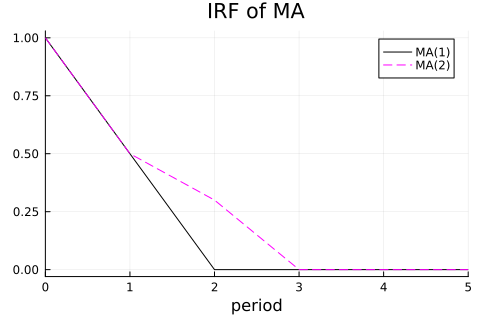

In [9]:
θ = 0.5              #MA(1)
(θ₁,θ₂) = (0.5,0.3)  #MA(2)

t_max = 15
ϵ     = zeros(t_max)
ϵ[1]  = 1                     #a single shock, otherwise zeros

y1 = ARMAFilter(ϵ,[],θ)
y2 = ARMAFilter(ϵ,[],[θ₁,θ₂])

p1 = plot( 0:t_max-1,[y1 y2],
           label = ["MA(1)" "MA(2)"],
           linecolor = [:black :magenta],
           linestyle = [:solid :dash],
           xlims = (0,5),
           xlabel = "period",
           title = "IRF of MA" )
display(p1)

## Autocorrelations of an MA(q)

It is straightforward to calculate the autocorrelations implied by an MA($q$) model. The next cell illustrates some results from the `MAqToAutocorr()` function (in local module).

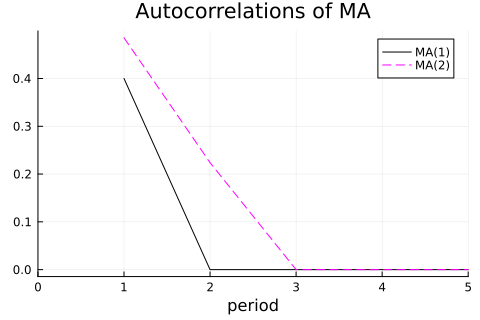

In [10]:
ρMA1 =  MAqToAutocorr([θ],t_max)        #using the θ values from above
ρMA2 =  MAqToAutocorr([θ₁,θ₂],t_max)

p1 = plot( 1:t_max,[ρMA1 ρMA2],
           label = ["MA(1)" "MA(2)"],
           linecolor = [:black :magenta],
           linestyle = [:solid :dash],
           xlims = (0,5),
           xlabel = "period",
           title = "Autocorrelations of MA" )
display(p1)

## Estimation of an MA(q) (extra)

To estimate an MA model, we apply MLE and use the [Optim.jl](https://github.com/JuliaNLSolvers/Optim.jl) package for the numerical optimization. 

The `MAqLL(par,y_data)` function (from local module) calculates the likelihood function and returns it as its first output. It is then used in the `MLE()` function to find the point estimates and calculate (different versions of) the VCV matrix.

Ideally, the MA model estimation should handle missing data. This can be done by using a Kalman filter (beyond the scope of this notebook) or GMM. Below, we use a simpler (approximate) approach by using the data where missings are replaced by 0.

In [11]:
par0 = [0.0,0.0,0,0,1]   #θ₁,θ₂,θ₃,θ₄,σ         #estimate an MA(4)

LLtFun_MA(par,y,x) = MAqLL(par,y)[1]            #log likelihood fn
(par,_,_,stdS,) = MLE(LLtFun_MA,par0,y_data0,nothing)

(θhat,σhat) = (par[1:end-1],par[end])

printblue("MLE of MA(4):\n")
printmat([θhat;σhat],stdS;colNames=["parameters","std"],rowNames=["θ₁","θ₂","θ₃","θ₄","σ"],width=15)

MLE of MA(4):

       parameters            std
θ₁         -0.055          0.021
θ₂         -0.007          0.024
θ₃         -0.013          0.020
θ₄         -0.027          0.019
σ           1.104          0.024



# AR(p)

This section discusses the properties and estimation of autoregressive (AR) processes.

## Rewriting an AR(p) as a VAR(1)

An easy way to do AR($p$) calculations is to first transform the AR($p$) to a VAR(1) (also called companion form) and then apply the rather straightforward formulas for VAR(1) models. This is discussed in detail somewhat later in the chapter, but it is a useful numerical tool, so we introduce it here.

For instance, an AR(2)

$y_t = a_1 y_{t-1} + a_2 y_{t-2} + \epsilon_t.$

can be written as a 2-variable VAR(1) 

$x_t = A_1 x_{t-1} + u_t,$

where 

$x_t = 
\begin{bmatrix} 
y_t \\ 
y_{t-1}  
\end{bmatrix} 
\text{ and }
A_1 = 
\begin{bmatrix} 
a_1 & a_2\\ 
1 & 0 
\end{bmatrix}.$

This is done in the `CompanionFormAR()` function (from local module).

In [12]:
(a₁,a₂) = (0.85,-0.5)                  #AR(2)
(A,Ω) = CompanionFormAR([a₁,a₂])       #A and the Var(shocks)

printblue("The VAR(1) matrix, A:")
printmat(A)

The VAR(1) matrix, A:
     0.850    -0.500
     1.000     0.000



## Impulse Response Function of an AR(p) Process

The IRF can be calculated by an explicit loop for the specific model. We do that below in order to show the basic idea. As a comparison, we apply the approach of first transforming to a VAR(1) and then using the simple formulas for that model

$ 
\partial x_{t+s}/\partial u_{j,t} = A^s e_j,
$
where is a vector of zeros, except that element $j$ is one. The function `VAR1IRF()` (from local module) does this.

(The `ARMAFilter()` function could also be used but this is not done here.)

The models used here is an AR(2)

$y_t = a_1 y_{t-1} + a_2 y_{t-2} + \epsilon_t.$

In [13]:
t_max = 15                #calculations by a simple loop

ϵ    = zeros(t_max)
ϵ[1] = 1                  #a single shock

y = copy(ϵ)
y[1] = ϵ[1]               #setting a₁*y[0] + a₂*y[-1] = 0
y[2] = a₁*y[1] + ϵ[2]     #setting a₂*y[0] = 0
for t in 3:t_max
    y[t] = a₁*y[t-1] + a₂*y[t-2] + ϵ[t]
end

In [14]:
irf_ar2 = VAR1IRF(A,t_max-1;m=1);     #same, but using VAR(1) function  
                                      #m=1 to pick out results for only 1 variable
#irf_ar2_ = ARMAFilter(ϵ,[a₁,a₂],[])
#printmat(y,irf_ar2,irf_ar2_)

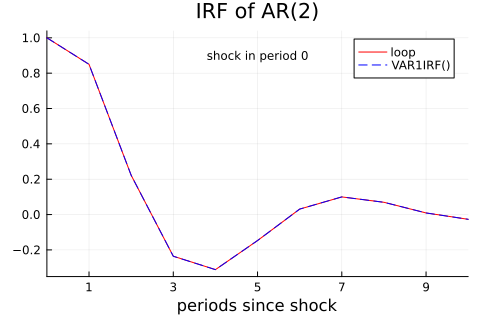

In [15]:
p1 = plot( 0:t_max-1,[y irf_ar2],
           linecolor = [:red :blue],
           linestyle = [:solid :dash],
           label = ["loop" "VAR1IRF()"],
           xticks = 1:2:t_max,
            xlims = (0,10),
           xlabel = "periods since shock",
           title = "IRF of AR(2)",
           annotation = (5,0.9,text("shock in period 0",8)) )
display(p1)

## Autocorrelations Implied by an AR(p) Process

by using `VAR1AutoCov()` (from local module)

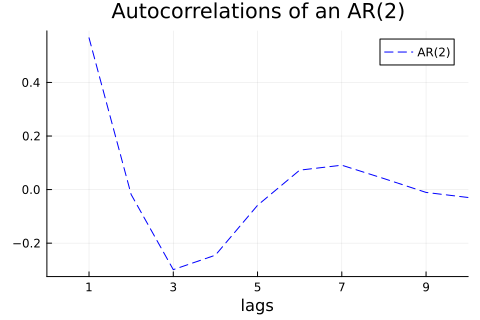

In [16]:
(_,_,ρ_ar2) = VAR1AutoCov(A,t_max;m=1)     #implied autocorrelations

p1 = plot( 1:t_max,ρ_ar2,
           label = "AR(2)",
           linecolor = :blue,
           linestyle = :dash,
           xticks = 1:2:t_max,
           xlims = (0,10),
           xlabel = "lags",
           title = "Autocorrelations of an AR(2)" )
display(p1)

## Estimation of an AR(p) Process

AR models can be estimated by OLS. 

The `ARpEst(y,p)` function (from local module) provides a simple way of doing this. It handles missing values.

In [17]:
#@doc2 ARpEst

#using CodeTracking
#println(@code_string ARpEst([1],2))    #print the source code

In [18]:
aAR1_data = ARpEst(y_data,1)
aAR2_data = ARpEst(y_data,2)
printlnPs("Estimated AR(1) coef: ",aAR1_data)
printlnPs("Estimated AR(2) coefs: ",aAR2_data)

Estimated AR(1) coef:     -0.055
Estimated AR(2) coefs:     -0.053    -0.009


## More Descriptive Statistics: Sample Partial Autocorrelations

The partial autocorrelation coefficient is the regression coefficients on $x_{t-p}$ in an AR($p$) regression, that is, on the last (non-constant) regressor. It is a useful tool for describing the properties of your data.

In [19]:
pac_data0 = pacf(y_data0,lags)             #from the StatsBase package, does not handle missings
pac_data = PartialAutoCorr(y_data,lags)    #from local module, handles missings

printblue("autocorrelations and  partial autocorrelations:\n")
printmat(pac_data0,pac_data;colNames=["pac (0)","pac"],rowNames=lags)

autocorrelations and  partial autocorrelations:

    pac (0)       pac
1    -0.054    -0.055
2    -0.009    -0.009
3    -0.014    -0.015
4    -0.028    -0.035
5    -0.010    -0.012



## The Roots of an AR(p) Model (extra)

The *roots* of an AR($p$) is a formal way of determining whether it is stationary. (An informal way is to check whether the impulse response function goes to zero as the horizon is extended.)

An easy way to calculate the roots is to first transform the AR($p$) to a VAR(1) and then calculate the eigenvalues of the VAR(1) matrix ($A$). If their absolute values are lower than one, then the model is stationary.

In [20]:
λ = eigen(A).values                #eigenvalues of the companion form

println("absolute values of the eigenvalues: should be < 1 for stationarity")
printmat(abs.(λ))

absolute values of the eigenvalues: should be < 1 for stationarity
     0.707
     0.707



## Forecasting with an AR(p) Process

Forecasts can be calculated in several ways. The perhaps easiest approach is to use the VAR(1) form and notice that 
$\mathrm{E}_t x_{t+s} = A^s x_t.$

The `VAR1Forecast()` (from local module) implements this.

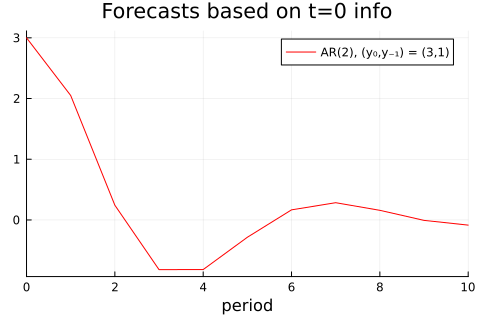

In [21]:
x_initial = [3,1]    #x[0],x[-1]

Ex, = VAR1Forecast(x_initial,A,t_max;m=1)       #applying VAR(1) function

p1 = plot( 0:t_max,Ex,
           label = "AR(2), (y₀,y₋₁) = (3,1)",
           linecolor = [:red :blue],
           linestyle = [:solid :dash],
            xlims = (0,10),
           xlabel = "period",
           title = "Forecasts based on t=0 info" )
display(p1)

# Approximating an MA(q) by an AR(p)

by using the Yule-Walker equations. 

The input is a vector of autocorrelations from an MA($q$) model, and the
output is the coefficients of an AR($p$) model to replicate those.

In the figure we compare the autocorrelations implied by the AR($p$) model to those of the original MA($q$) model.

In [22]:
a2 = YuleWalker([1;ρMA2[1:2]])         #use the first 2 or 3 autocorrelations from an MA(2)
a3 = YuleWalker([1;ρMA2[1:3]])

printblue("MA(2)")
printmat([θ₁,θ₂],rowNames=["θ₁","θ₂"])

printblue("AR(2) coefs needed to approximate an MA(2)")
printmat(a2;rowNames=["a₁","a₂"])

printblue("AR(3) coefs needed to approximate an MA(2) even better")
printmat(a3;rowNames=["a₁","a₂","a₃"])

MA(2)
θ₁     0.500
θ₂     0.300

AR(2) coefs needed to approximate an MA(2)
a₁     0.492
a₂    -0.015

AR(3) coefs needed to approximate an MA(2) even better
a₁     0.490
a₂     0.051
a₃    -0.135



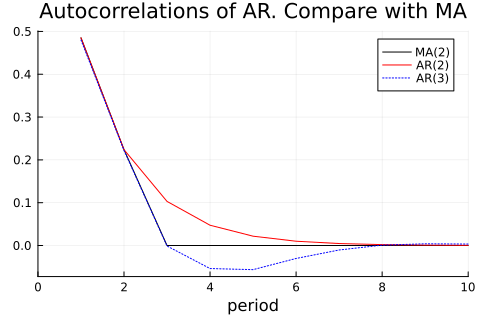

In [23]:
A_ar2, = CompanionFormAR(a2)                   #AR(2) to companion form
(_,_,ρ_ar2) = VAR1AutoCov(A_ar2,t_max;m=1)     #implied autocorrelations

A_ar3, = CompanionFormAR(a3)                   #AR(3) to companion form
(_,_,ρ_ar3) = VAR1AutoCov(A_ar3,t_max;m=1)     #implied autocorrelations

p1 = plot( 1:t_max,[ρMA2 ρ_ar2 ρ_ar3],
           label = ["MA(2)" "AR(2)" "AR(3)"],
           linecolor = [:black :red :blue],
           linestyle = [:solid :solid :dot],
           xlims = (0,10),
           xlabel = "period",
           title = "Autocorrelations of AR. Compare with MA" )
display(p1)

# VAR(p)

This section some of the calculations for vector autoregressive (VAR) processes. 
Formally, this is very similar to the computations for the AR($p$) above, since we 
used the approach of converting the AR() model to a VAR(1). However, there is one key
difference: we are now interested in the results for more than one (the first) 
variable.

To illustrate this, consider a VAR(2)

$y_t = A_1 y_{t-1} + A_2 y_{t-2} + \epsilon_t,$

where $y_t$ and $y_{t-1}$ are vectors with two elements and

$A_1 = 
\begin{bmatrix} 
0.5 & 0.2\\ 
0.1 & -0.3 
\end{bmatrix}$

$A_2 = 
\begin{bmatrix} 
0.1 & 0.1\\ 
0.1 & 0.2 
\end{bmatrix}$

or we change $A_2$ to a matrix of zeros to compare with the results in the lecture notes.

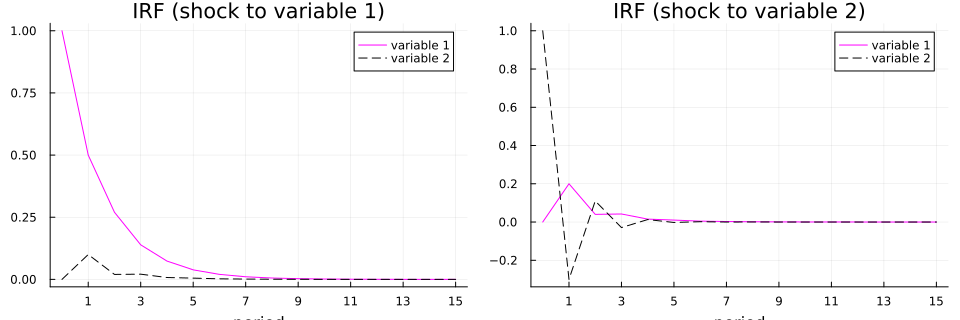

In [24]:
A1 = [0.5 0.2;
      0.1 -0.3]
#A2 = [0.1 0.1;                      #try also this
#      0.1 0.2]
A2 = zeros(2,2)

Ap = cat(A1,A2,dims=3)
A, = CompanionFormVAR(Ap)             #convert VAR(2) to larger VAR(1)
irf_var2 = VAR1IRF(A,t_max;m=2)          

p1 = plot( 0:t_max,irf_var2[:,:,1],
           label = ["variable 1" "variable 2"],
           linecolor = [:magenta :black],
           linestyle = [:solid :dash],
           xticks = 1:2:t_max,
           xlabel = "period",
           title = "IRF (shock to variable 1)" )

p2 = plot( 0:t_max,irf_var2[:,:,2],
           label = ["variable 1" "variable 2"],
           linecolor = [:magenta :black],
           linestyle = [:solid :dash],
           xticks = 1:2:t_max,
           xlabel = "period",
           title = "IRF (shock to variable 2)" )

p = plot(p1,p2,layout=(1,2),size=(480*2,320))
display(p)

# Non-Stationary Processes

The cells below shows the impulse response function and the roots of a non-stationary AR(3).

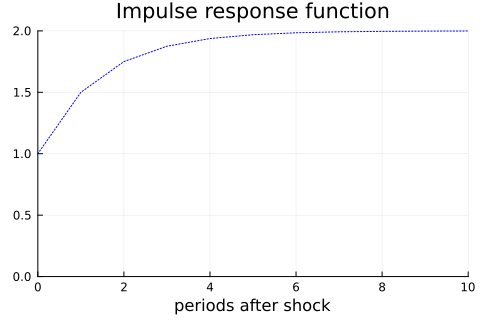

In [25]:
a = [1.5,-0.5]                      #AR(2) coefficients
A, = CompanionFormAR(a)

irf_ar3 = VAR1IRF(A,t_max-1;m=1)

p1 = plot( 0:t_max-1,irf_ar3,
           label = "",
           linecolor = :blue,
           linestyle = :dot,
           #xticks = 1:2:t_max,
           ylims = (0,2),
           xlims = (0,10),
           xlabel = "periods after shock",
           title = "Impulse response function" )
display(p1)

In [26]:
λ = eigen(A).values    #eigenvalues of the companion form

println("absolute values of the eigenvalues: should be < 1 for stationarity")
printmat(abs.(λ))

absolute values of the eigenvalues: should be < 1 for stationarity
     0.500
     1.000

